In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
from pathlib import Path
import sys, os

## Carga del dataset (1 semana)

In [69]:
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("Las variables de entorno MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

lista_dfs = []

for i in range(1, 28):
    date = f"2025-08-{i:02d}" 
    ruta_archivo = f"grupo5/cleaned/clima_clean/date={date}/clima_{date}.parquet"
    
    df_dia = download_df_parquet(access_key, secret_key, ruta_archivo)
    
    lista_dfs.append(df_dia)

df = pd.concat(lista_dfs, ignore_index=True)

df

,Date,Temperature,Rain,Precipitation,Wind Speed,Snow,Cloud Cover,apparent_temp,precip_3h_accum,is_freezing,is_high_wind,hour,is_rush_hour
0,2025-08-01 00:00:00+00:00,23.650000,0.2,0.2,23.453938,0.0,100.0,24.517115,0.2,0,0,0,0
1,2025-08-01 01:00:00+00:00,23.950001,0.5,0.5,33.625809,0.0,100.0,24.716435,0.7,0,0,1,0
2,2025-08-01 02:00:00+00:00,23.200001,1.2,1.2,38.445908,0.0,100.0,23.645878,1.9,0,0,2,0
3,2025-08-01 03:00:00+00:00,22.400000,1.1,1.1,44.068764,0.0,100.0,22.481428,2.8,0,0,3,0
4,2025-08-01 04:00:00+00:00,21.650000,0.1,0.1,46.478008,0.0,100.0,21.426679,2.4,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,2025-08-27 19:00:00+00:00,22.549999,0.0,0.0,28.220417,0.0,65.0,22.990018,0.0,0,0,19,1
643,2025-08-27 20:00:00+00:00,22.650000,0.0,0.0,26.639999,0.0,34.0,23.157251,0.0,0,0,20,0
644,2025-08-27 21:00:00+00:00,22.900000,0.0,0.0,24.627787,0.0,41.0,23.528578,0.0,0,0,21,0
645,2025-08-27 22:00:00+00:00,22.900000,0.0,0.0,26.065218,0.0,57.0,23.493714,0.0,0,0,22,0


## Análisis de componentes generales

### Información general del dataset (estructura y tipo de datos)

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   Date             647 non-null    datetime64[ms, UTC]
 1   Temperature      647 non-null    float32            
 2   Rain             647 non-null    float32            
 3   Precipitation    647 non-null    float32            
 4   Wind Speed       647 non-null    float32            
 5   Snow             647 non-null    float32            
 6   Cloud Cover      647 non-null    float32            
 7   apparent_temp    647 non-null    float64            
 8   precip_3h_accum  647 non-null    float64            
 9   is_freezing      647 non-null    int64              
 10  is_high_wind     647 non-null    int64              
 11  hour             647 non-null    int32              
 12  is_rush_hour     647 non-null    int64              
dtypes: datetime64[ms, UTC](1), floa

### Comprobación de calidad (nulos y duplicados)

In [71]:
print("\n--- Conteo de Valores Nulos por Columna ---")
display(df.isnull().sum())

print("\n--- Filas Duplicadas ---")
num_duplicados = df.duplicated().sum()
print(f"Número de filas completamente duplicadas: {num_duplicados}")


--- Conteo de Valores Nulos por Columna ---


Date               0
Temperature        0
Rain               0
Precipitation      0
Wind Speed         0
Snow               0
Cloud Cover        0
apparent_temp      0
precip_3h_accum    0
is_freezing        0
is_high_wind       0
hour               0
is_rush_hour       0
dtype: int64


--- Filas Duplicadas ---
Número de filas completamente duplicadas: 0


### Comprobación del rango temporal del dataset (para poder cruzarlo con otros)

In [72]:
fecha_inicio = df['Date'].min()
fecha_fin = df['Date'].max()

print(f"\nRango temporal del dataset:")
print(f"Desde: {fecha_inicio}")
print(f"Hasta: {fecha_fin}")
print(f"Total de registros (horas observadas): {len(df)}")


Rango temporal del dataset:
Desde: 2025-08-01 00:00:00+00:00
Hasta: 2025-08-27 23:00:00+00:00
Total de registros (horas observadas): 647


## Análisis univariante (Características de las variables)

### Estadísticas de las variables continuas

In [73]:
display(df.describe().round(2))

,Temperature,Rain,Precipitation,Wind Speed,Snow,Cloud Cover,apparent_temp,precip_3h_accum,is_freezing,is_high_wind,hour,is_rush_hour
count,647.00,647.00,647.00,647.00,647.0,647.00,647.00,647.00,647.0,647.00,647.00,647.00
mean,22.26,0.06,0.06,21.27,0.0,40.86,22.86,0.19,0.0,0.01,11.48,0.29
std,1.29,0.57,0.57,10.04,0.0,43.68,1.76,1.32,0.0,0.11,6.92,0.46
min,18.65,0.00,0.00,0.90,0.0,0.00,17.45,0.00,0.0,0.00,0.00,0.00
25%,21.50,0.00,0.00,13.89,0.0,0.00,21.89,0.00,0.0,0.00,5.50,0.00
50%,22.20,0.00,0.00,19.96,0.0,17.00,22.93,0.00,0.0,0.00,11.00,0.00
75%,23.15,0.00,0.00,26.28,0.0,99.00,24.17,0.00,0.0,0.00,17.00,1.00
max,25.70,12.70,12.70,53.92,0.0,100.00,26.99,20.60,0.0,1.00,23.00,1.00


### Gráficos de distribución de las variables climáticas continuas

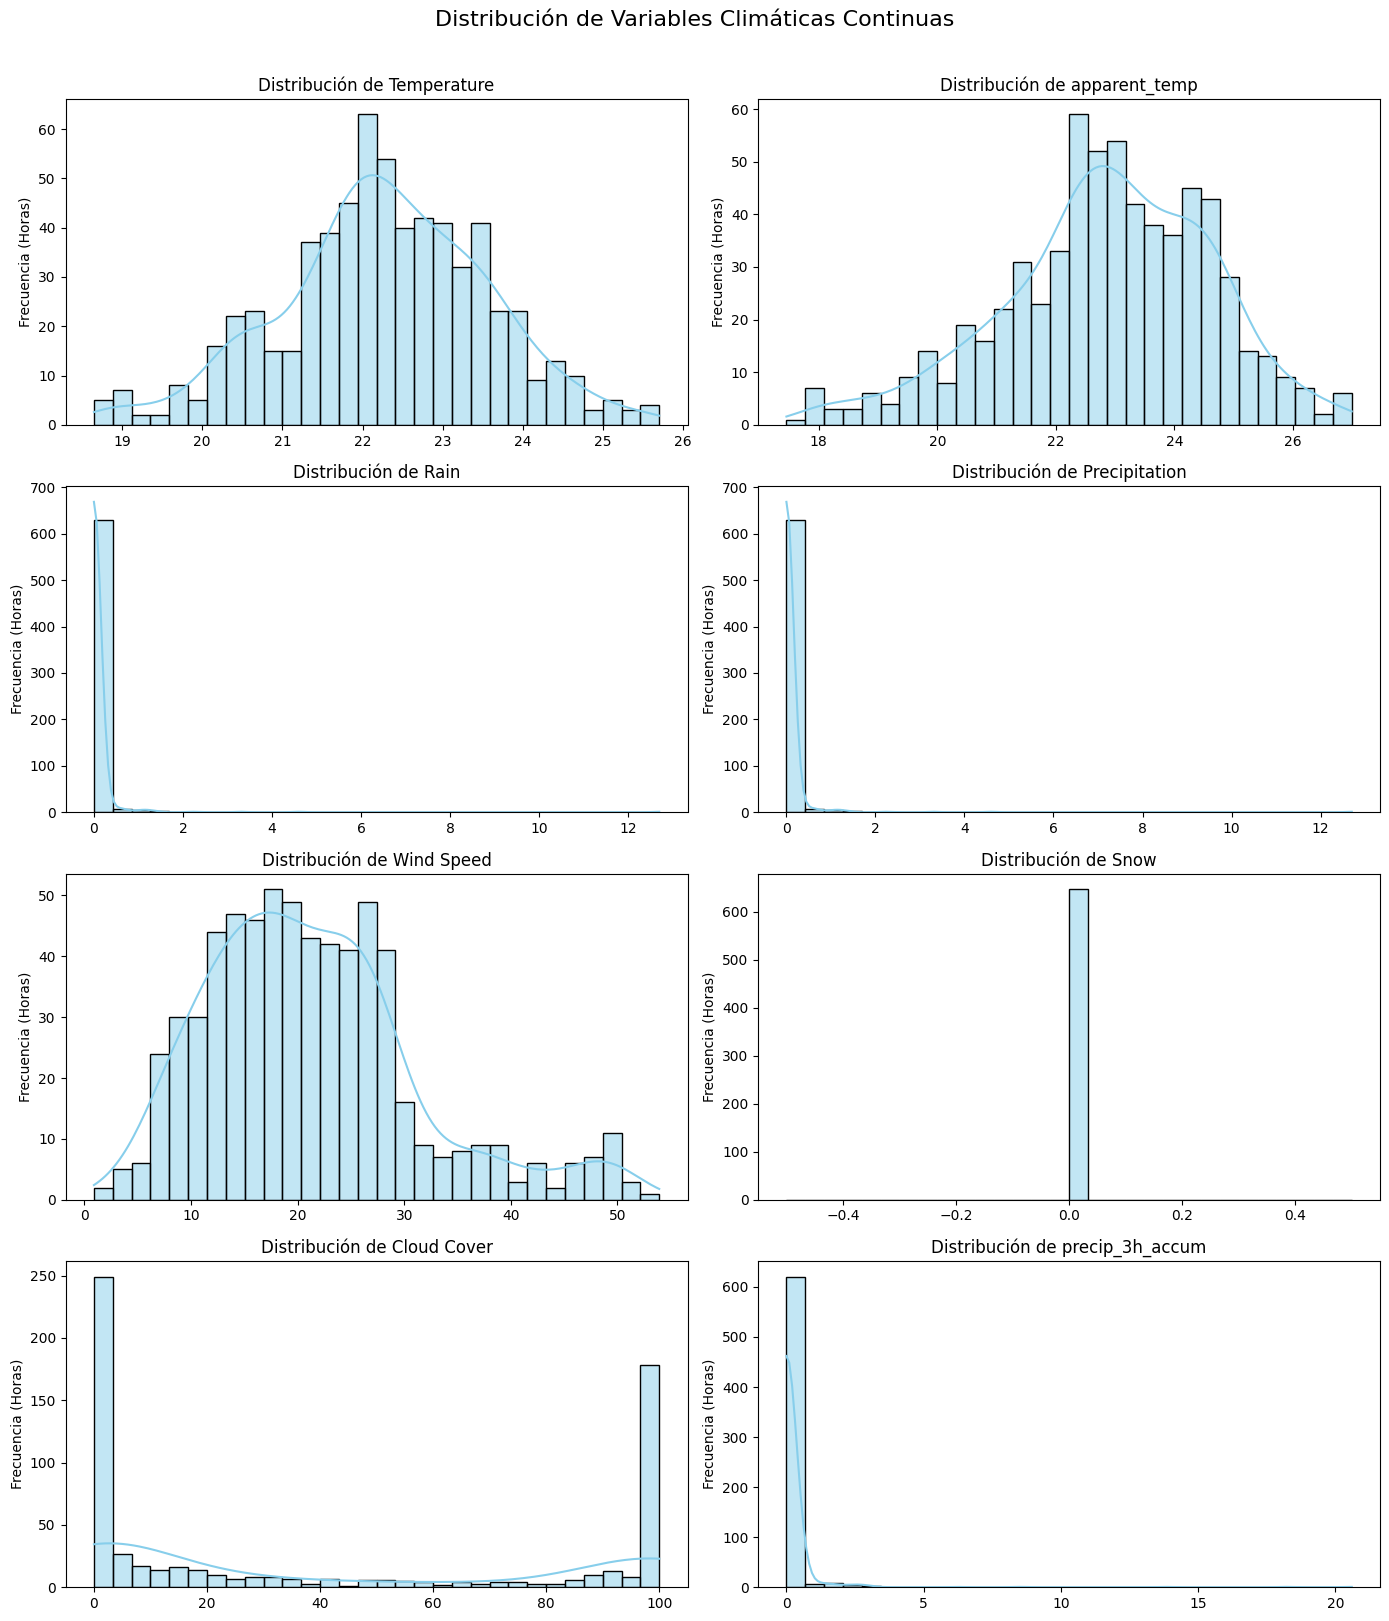

In [74]:
vars_continuas = [
    'Temperature', 'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed', 'Snow', 'Cloud Cover', 'precip_3h_accum'
]

ncols = 2
nrows = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 16))
fig.suptitle('Distribución de Variables Climáticas Continuas', fontsize=16, y=1.01)

axes = axes.flatten()

# Bucle para dibujar cada variable
for i, var in enumerate(vars_continuas):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia (Horas)')

plt.tight_layout()
plt.show()

### Boxplots para detectar outliers

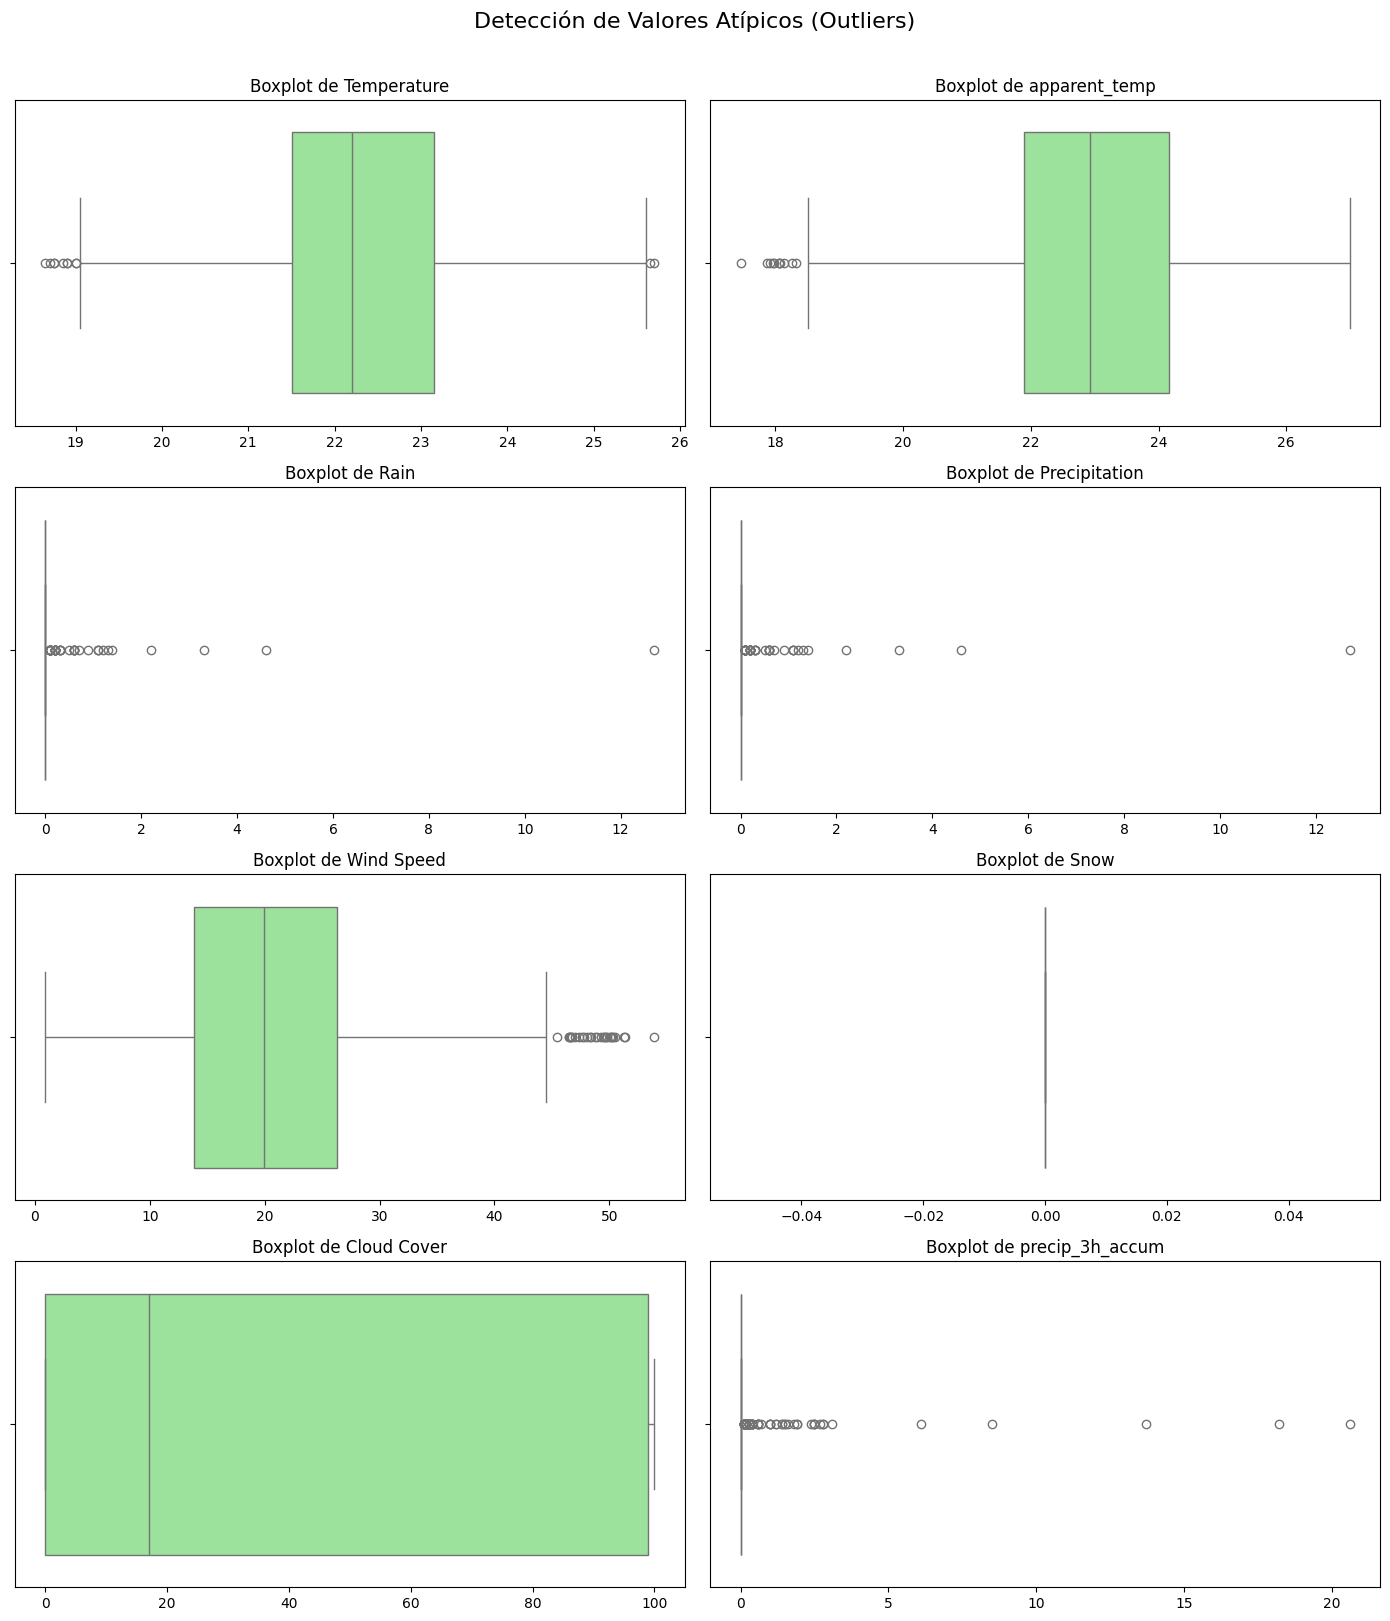

In [75]:
vars_continuas = [
    'Temperature', 'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed', 'Snow', 'Cloud Cover', 'precip_3h_accum'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Detección de Valores Atípicos (Outliers)', fontsize=16, y=1.01)

axes = axes.flatten()

for i, var in enumerate(vars_continuas):
    sns.boxplot(x=df[var], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot de {var}', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Frecuencia de las variables binarias 

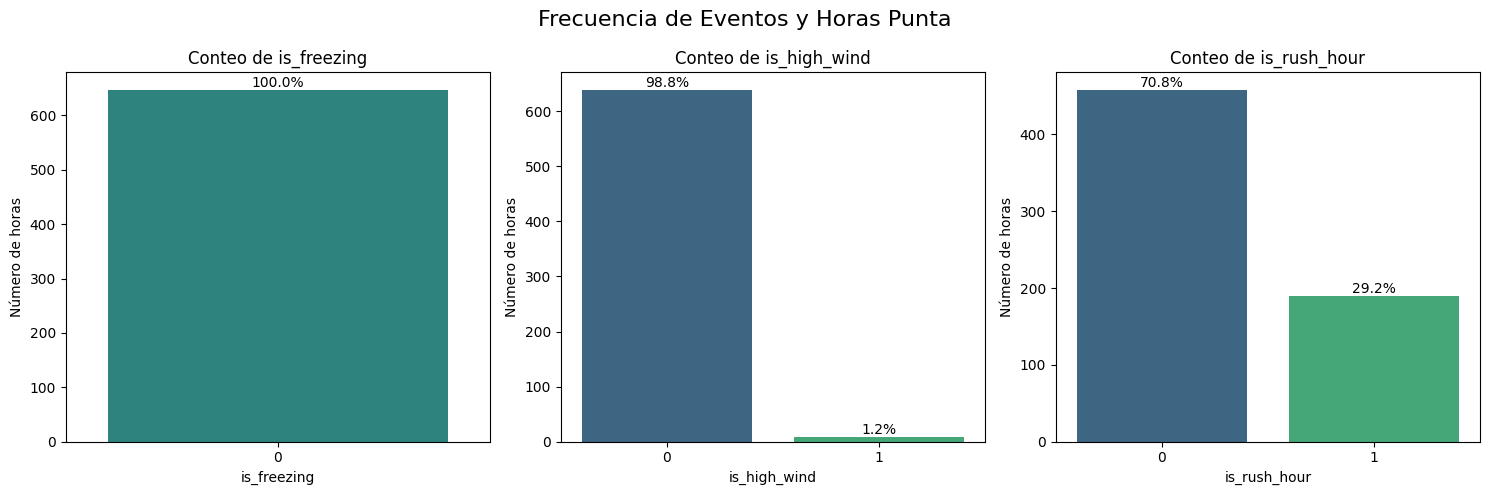

In [76]:
vars_binarias = ['is_freezing', 'is_high_wind', 'is_rush_hour']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Frecuencia de Eventos y Horas Punta', fontsize=16)

for i, var in enumerate(vars_binarias):
    sns.countplot(x=var, data=df, ax=axes[i], palette='viridis', hue=var, legend=False)
    
    axes[i].set_title(f'Conteo de {var}')
    axes[i].set_ylabel('Número de horas')
    
    total = len(df[var])
    for p in axes[i].patches:
        porcentaje = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Análisis bivariante (Relaciones entre variables predictoras)

### Matriz de correlación (variables numéricas: continuas y binarias)

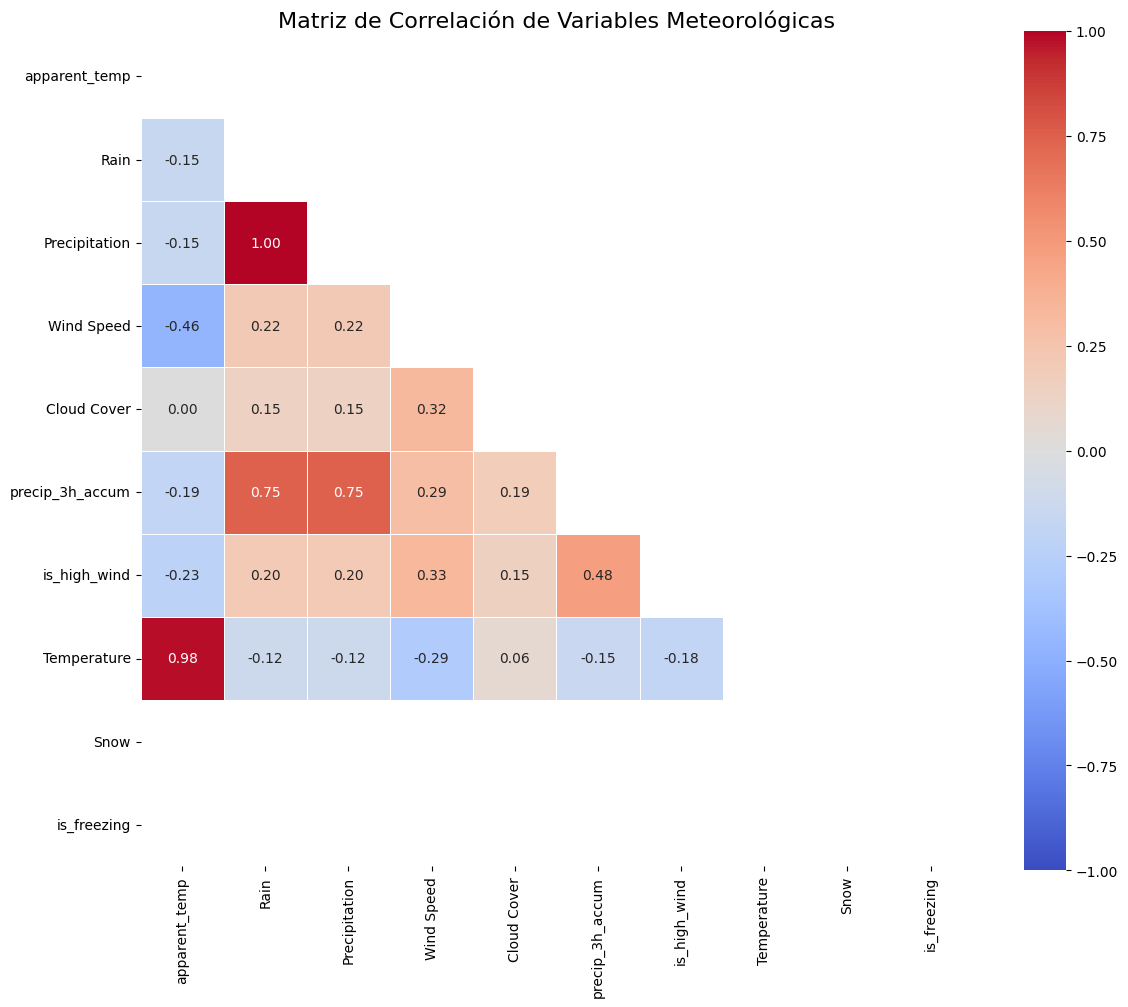

In [77]:
vars_numericas = [
    'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed',  'Cloud Cover', 'precip_3h_accum',
    'is_high_wind', 'Temperature', 'Snow','is_freezing'

] 

matriz_corr = df[vars_numericas].corr()

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación de Variables Meteorológicas', fontsize=16)

sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            annot_kws={"size": 10})

plt.tight_layout()
plt.show()

### Análisis de colinealidad: pares con correlación |r| > 0.85

In [78]:
corr_unstacked = matriz_corr.abs().unstack()

# Filtramos las que son mayores a 0.85 pero menores a 1.0 (para que no salga Temperatura vs Temperatura)
alta_corr = corr_unstacked[(corr_unstacked > 0.85) & (corr_unstacked < 1.0)]

if alta_corr.empty:
    print("No se encontraron variables altamente correlacionadas.")
else:
    display(alta_corr.drop_duplicates().to_frame(name='Correlación'))

,,Correlación
apparent_temp,Temperature,0.981546


## Relación con la variable a predecir

### Cargamos los dataset de trenes

In [80]:
lista_dfs = []

for i in range(1, 28):
    date = f"2025-08-{i:02d}" 
    ruta_archivo = f"grupo5/cleaned/gtfs_clean_scheduled/date={date}/gtfs_scheduled_{date}.parquet"
    
    df_dia = download_df_parquet(access_key, secret_key, ruta_archivo)
    
    lista_dfs.append(df_dia)

df_trenes_scheduled = pd.concat(lista_dfs, ignore_index=True)

df_trenes_scheduled

,trip_uid,match_key,route_id,stop_id,is_unscheduled,scheduled_seconds,actual_seconds,delay_seconds,delay_minutes,service_date,...,rolling_mean_delay_trip,target_delay_10m,target_delay_20m,target_delay_30m,target_delay_end,scheduled_time_to_end,stops_to_end,delta_delay_10m,delta_delay_20m,delta_delay_30m
0,1754020890_6..N04X104,024150_6..N04X104,6,621N,False,14490.0,NaN,NaN,NaN,2025-08-01,...,NaN,NaN,NaN,NaN,132.0,0.0,0,NaN,NaN,NaN
1,1754020890_6..N04X104,024150_6..N04X104,6,619N,False,14700.0,14777.0,77.0,1.283333,2025-08-01,...,NaN,117.0,154.0,172.0,132.0,-210.0,18,40.0,77.0,95.0
2,1754020890_6..N04X104,024150_6..N04X104,6,618N,False,14790.0,14885.0,95.0,1.583333,2025-08-01,...,77.000000,105.0,150.0,162.0,132.0,-300.0,17,10.0,55.0,67.0
3,1754020890_6..N04X104,024150_6..N04X104,6,617N,False,14850.0,14962.0,112.0,1.866667,2025-08-01,...,86.000000,134.0,139.0,132.0,132.0,-360.0,16,22.0,27.0,20.0
4,1754020890_6..N04X104,024150_6..N04X104,6,616N,False,14970.0,15086.0,116.0,1.933333,2025-08-01,...,94.666667,118.0,149.0,NaN,132.0,-480.0,15,2.0,33.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4094204,1756352160_SI.S03R,021600_SI.S03R,SI,S15S,False,14940.0,15072.0,132.0,2.200000,2025-08-27,...,148.666667,NaN,NaN,NaN,122.0,540.0,4,NaN,NaN,NaN
4094205,1756352160_SI.S03R,021600_SI.S03R,SI,S14S,False,15060.0,15196.0,136.0,2.266667,2025-08-27,...,156.333333,NaN,NaN,NaN,122.0,420.0,3,NaN,NaN,NaN
4094206,1756352160_SI.S03R,021600_SI.S03R,SI,S13S,False,15180.0,15330.0,150.0,2.500000,2025-08-27,...,166.333333,NaN,NaN,NaN,122.0,300.0,2,NaN,NaN,NaN
4094207,1756352160_SI.S03R,021600_SI.S03R,SI,S11S,False,15300.0,15439.0,139.0,2.316667,2025-08-27,...,139.333333,NaN,NaN,NaN,122.0,180.0,1,NaN,NaN,NaN


In [81]:
df_trenes_scheduled['Date'] = pd.to_datetime(df_trenes_scheduled['service_date'], utc=True)

df_trenes_scheduled['hour'] = (df_trenes_scheduled['actual_seconds'] // 3600)

df_trenes_scheduled['hour'] = df_trenes_scheduled['hour'].fillna(-1).astype(int)

print("Comprobando compatibilidad antes del cruce")
print(f"Trenes - Fecha min: {df_trenes_scheduled['Date'].min()}, max: {df_trenes_scheduled['Date'].max()}")
print(f"Clima  - Fecha min: {df['Date'].min()}, max: {df['Date'].max()}")

df_master = pd.merge(df_trenes_scheduled, df, on=['Date', 'hour'], how='inner')

# Eliminamos los posibles casos donde la hora era -1 (nula)
df_master = df_master[df_master['hour'] != -1]

Comprobando compatibilidad antes del cruce
Trenes - Fecha min: 2025-08-01 00:00:00+00:00, max: 2025-08-27 00:00:00+00:00
Clima  - Fecha min: 2025-08-01 00:00:00+00:00, max: 2025-08-27 23:00:00+00:00


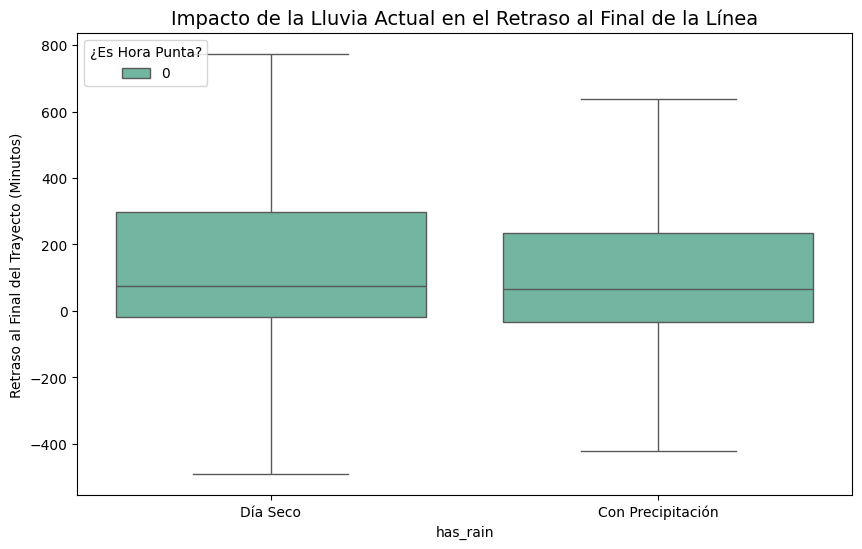

In [82]:
df_plot = df_master.dropna(subset=['target_delay_end']).copy()
df_plot['has_rain'] = df_plot['Precipitation'] > 0

plt.figure(figsize=(10, 6))
# Usamos un boxplot sin outliers extremos (showfliers=False) para ver la mediana claramente
sns.boxplot(
    data=df_plot, 
    x='has_rain', 
    y='target_delay_end', 
    hue='is_peak', 
    palette='Set2', 
    showfliers=False
)

plt.title('Impacto de la Lluvia Actual en el Retraso al Final de la Línea', fontsize=14)
plt.ylabel('Retraso al Final del Trayecto (Minutos)')
plt.xticks([0, 1], ['Día Seco', 'Con Precipitación'])
plt.legend(title='¿Es Hora Punta?', loc='upper left')
plt.show()

C:\Users\2alex\AppData\Local\Temp\ipykernel_35240\1925001095.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


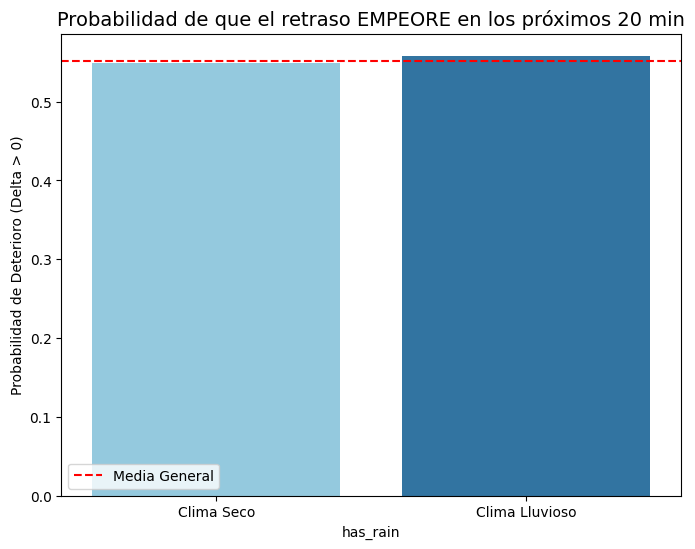

In [83]:
df_plot_delta = df_master.dropna(subset=['delta_delay_20m']).copy()
df_plot_delta['has_rain'] = df_plot_delta['Precipitation'] > 0

# Calculamos la probabilidad de que el retraso EMPEORE en los próximos 20 min (delta > 0)
df_plot_delta['empeora_20m'] = (df_plot_delta['delta_delay_20m'] > 0).astype(int)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_plot_delta, 
    x='has_rain', 
    y='empeora_20m',
    palette=['#87CEEB', '#1f77b4'],
    errorbar=None
)

plt.title('Probabilidad de que el retraso EMPEORE en los próximos 20 min', fontsize=14)
plt.ylabel('Probabilidad de Deterioro (Delta > 0)')
plt.xticks([0, 1], ['Clima Seco', 'Clima Lluvioso'])
# Añadimos una línea horizontal con la media general para comparar
plt.axhline(df_plot_delta['empeora_20m'].mean(), color='red', linestyle='--', label='Media General')
plt.legend()
plt.show()

### Comparación 1: Retraso (delay_minutes) vs Lluvia (precipitation)

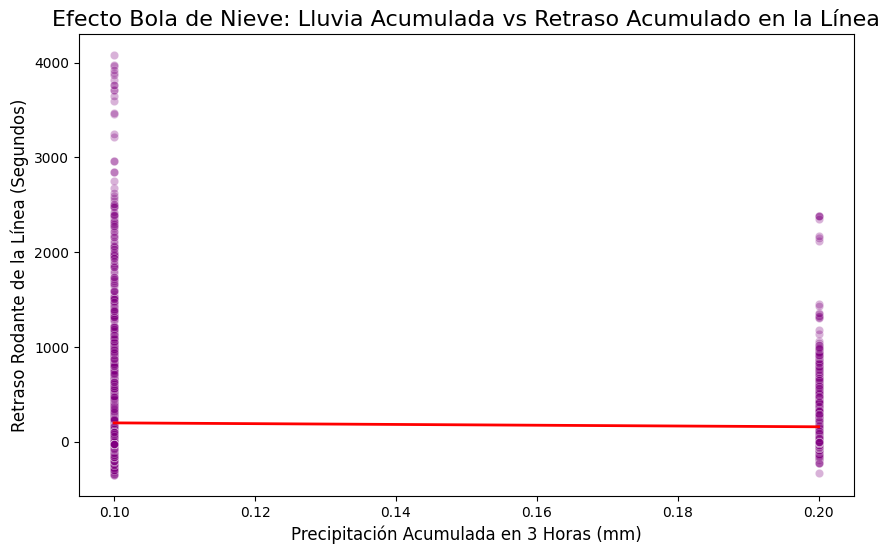

In [84]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_master[df_master['precip_3h_accum'] > 0], 
    x='precip_3h_accum', 
    y='route_rolling_delay', 
    alpha=0.3, 
    color='purple'
)

sns.regplot(
    data=df_master[df_master['precip_3h_accum'] > 0], 
    x='precip_3h_accum', 
    y='route_rolling_delay', 
    scatter=False, 
    color='red',
    line_kws={'linewidth': 2}
)

plt.title('Efecto Bola de Nieve: Lluvia Acumulada vs Retraso Acumulado en la Línea', fontsize=16)
plt.xlabel('Precipitación Acumulada en 3 Horas (mm)', fontsize=12)
plt.ylabel('Retraso Rodante de la Línea (Segundos)', fontsize=12)
plt.show()

C:\Users\2alex\AppData\Local\Temp\ipykernel_35240\2801908573.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


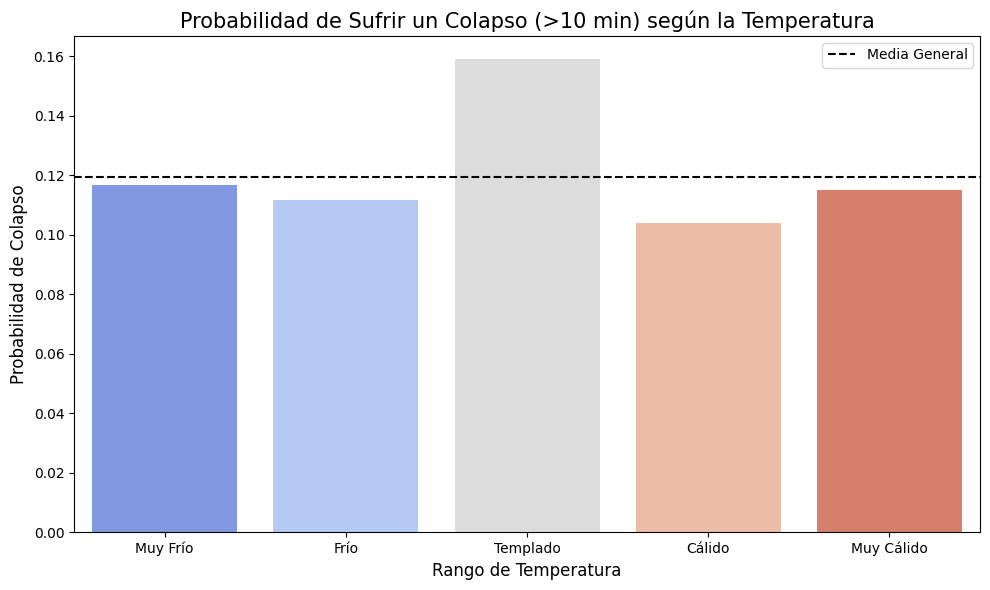

In [85]:
# 1. Definimos qué es un colapso (ej: más de 10 min de retraso)
df_master['retraso_critico'] = (df_master['delay_minutes'] > 10).astype(int)

# 2. Dividimos la Temperatura en 5 grupos iguales (del más frío al más cálido)
df_master['temp_bins'] = pd.qcut(
    df_master['Temperature'], 
    q=5, 
    labels=['Muy Frío', 'Frío', 'Templado', 'Cálido', 'Muy Cálido']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_master, 
    x='temp_bins', 
    y='retraso_critico', 
    palette='coolwarm', 
    errorbar=None
)

# Añadimos la media general como referencia
plt.axhline(df_master['retraso_critico'].mean(), color='black', linestyle='--', label='Media General')

plt.title('Probabilidad de Sufrir un Colapso (>10 min) según la Temperatura', fontsize=15)
plt.ylabel('Probabilidad de Colapso', fontsize=12)
plt.xlabel('Rango de Temperatura', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

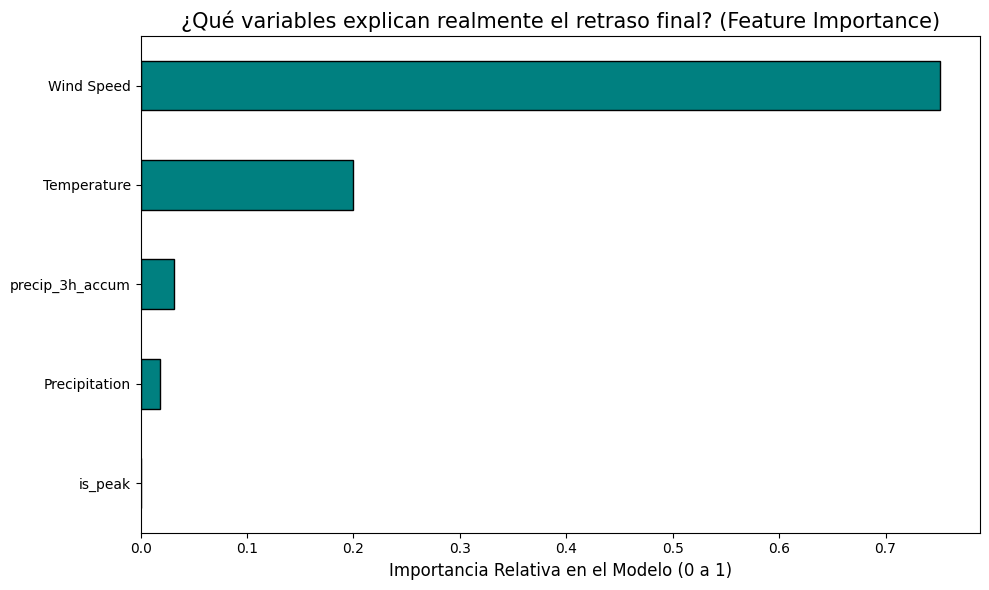

In [86]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1. Elegimos las variables que queremos poner a competir
features = ['Temperature', 'Precipitation', 'Wind Speed', 'precip_3h_accum', 'is_peak']

target = 'target_delay_end'

# 2. Limpiamos nulos y sacamos una muestra de 50.000 filas para que se ejecute en 2 segundos
df_rf = df_master.dropna(subset=features + [target]).sample(n=min(50000, len(df_master)), random_state=42)

# 3. Entrenamos un bosque aleatorio pequeño
rf = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(df_rf[features], df_rf[target])

# 4. Extraemos y graficamos la importancia de las variables
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('¿Qué variables explican realmente el retraso final? (Feature Importance)', fontsize=15)
plt.xlabel('Importancia Relativa en el Modelo (0 a 1)', fontsize=12)
plt.tight_layout()
plt.show()

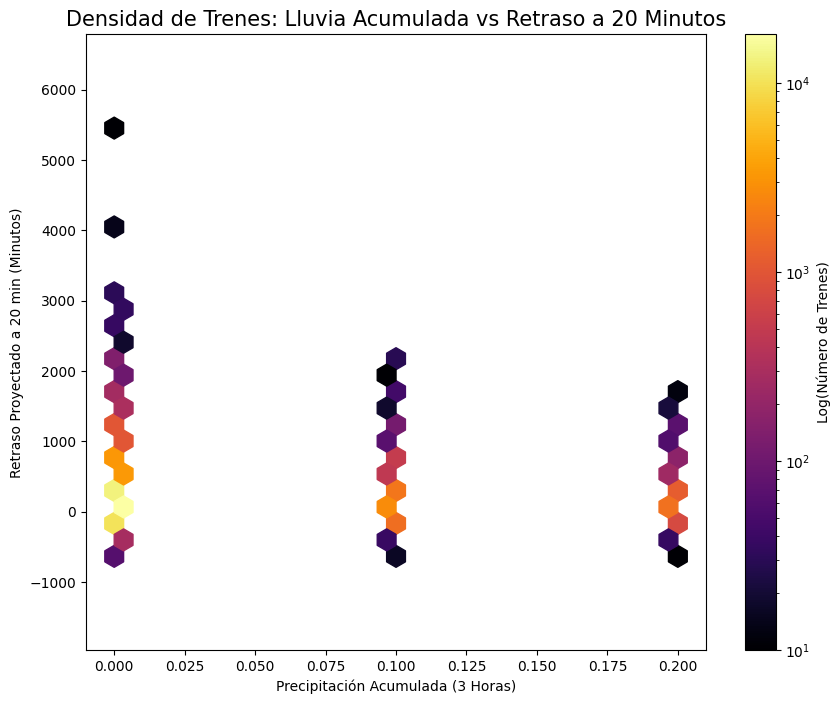

In [87]:
plt.figure(figsize=(10, 8))

# Usamos hexbin para ver densidades en datasets masivos
# Cambia 'precip_3h_accum' por 'Wind Speed' si quieres probar el viento
hb = plt.hexbin(
    x=df_master['precip_3h_accum'], 
    y=df_master['target_delay_20m'], 
    gridsize=30, 
    cmap='inferno', 
    mincnt=10, # Solo pinta hexágonos si hay más de 10 trenes ahí
    bins='log' # Escala logarítmica porque la mayoría de trenes están en 0 retraso
)

plt.colorbar(hb, label='Log(Número de Trenes)')
plt.title('Densidad de Trenes: Lluvia Acumulada vs Retraso a 20 Minutos', fontsize=15)
plt.xlabel('Precipitación Acumulada (3 Horas)')
plt.ylabel('Retraso Proyectado a 20 min (Minutos)')
plt.show()

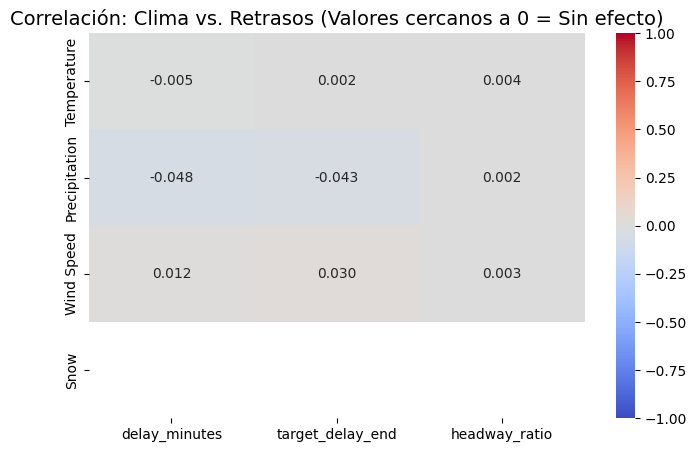

In [88]:
# Seleccionamos las variables del clima y las de retraso
cols_clima = ['Temperature', 'Precipitation', 'Wind Speed', 'Snow']
cols_trenes = ['delay_minutes', 'target_delay_end', 'headway_ratio']

# Calculamos la correlación solo entre estos dos grupos
corr_matrix = df_master[cols_clima + cols_trenes].corr().loc[cols_clima, cols_trenes]

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, vmax=1,
    fmt=".3f"
)
plt.title('Correlación: Clima vs. Retrasos (Valores cercanos a 0 = Sin efecto)', fontsize=14)
plt.show()

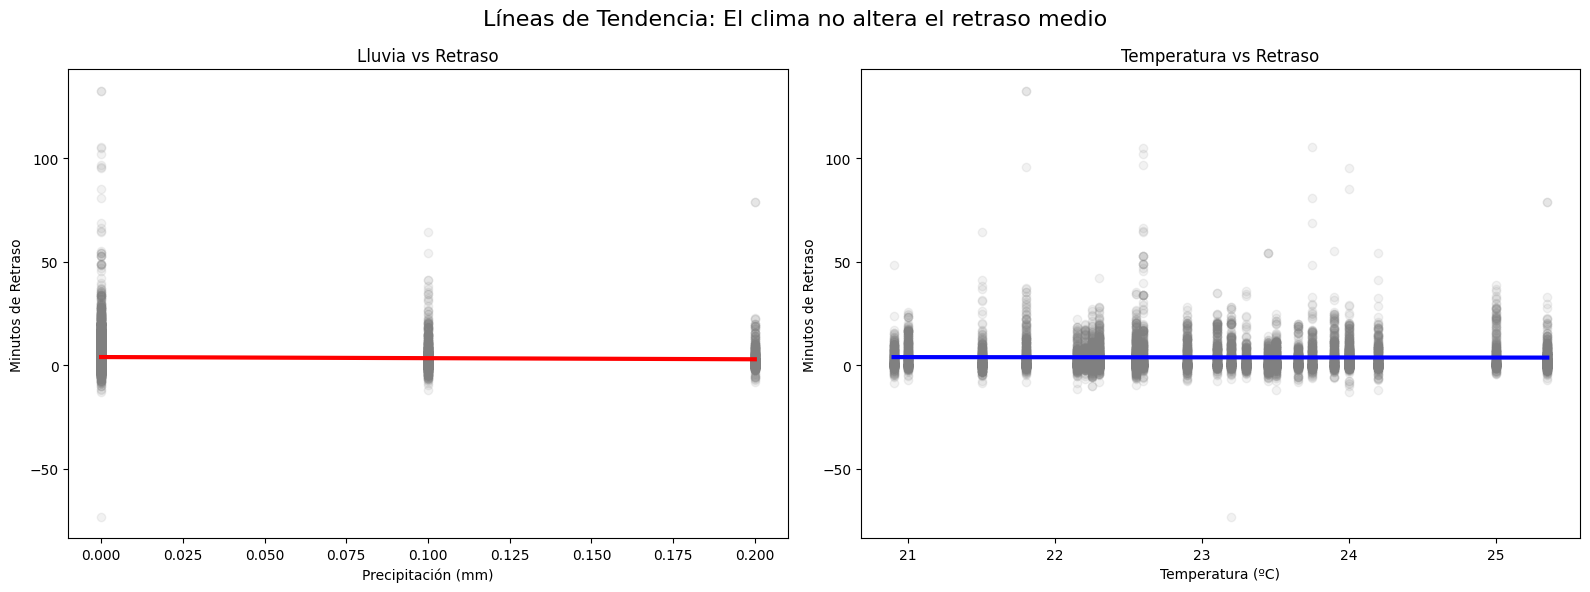

In [89]:
# Hacemos una muestra de 10,000 puntos para que el gráfico cargue rápido
df_sample = df_master.dropna(subset=['Precipitation', 'delay_minutes']).sample(n=min(10000, len(df_master)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Líneas de Tendencia: El clima no altera el retraso medio', fontsize=16)

# Gráfico 1: Lluvia vs Retraso
sns.regplot(
    data=df_sample, 
    x='Precipitation', 
    y='delay_minutes', 
    ax=axes[0], 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'red', 'linewidth': 3}
)
axes[0].set_title('Lluvia vs Retraso')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Minutos de Retraso')

# Gráfico 2: Temperatura vs Retraso
sns.regplot(
    data=df_sample, 
    x='Temperature', 
    y='delay_minutes', 
    ax=axes[1], 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'blue', 'linewidth': 3}
)
axes[1].set_title('Temperatura vs Retraso')
axes[1].set_xlabel('Temperatura (ºC)')
axes[1].set_ylabel('Minutos de Retraso')

plt.tight_layout()
plt.show()

C:\Users\2alex\AppData\Local\Temp\ipykernel_35240\4137407992.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


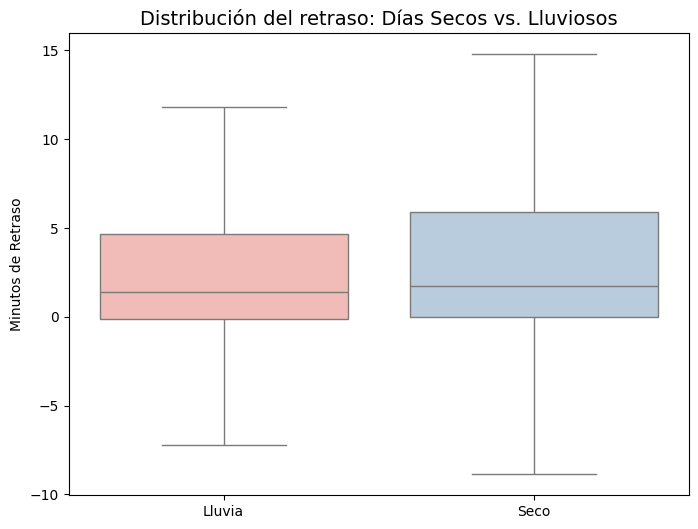

In [90]:
# Creamos una variable binaria simple
df_master['condicion_clima'] = df_master['Precipitation'].apply(lambda x: 'Lluvia' if x > 0 else 'Seco')

plt.figure(figsize=(8, 6))
# showfliers=False quita los puntos extremos para ver claramente dónde está el grueso de los trenes
sns.boxplot(
    data=df_master, 
    x='condicion_clima', 
    y='delay_minutes', 
    palette='Pastel1',
    showfliers=False 
)

plt.title('Distribución del retraso: Días Secos vs. Lluviosos', fontsize=14)
plt.ylabel('Minutos de Retraso')
plt.xlabel('')
plt.show()

In [36]:

df_master['Wind Speed'].quantile(0.95)

np.float64(45.92787170410156)

## 1) Creación de banderas de clima extremo (Umbrales)

In [91]:
# Banderas de clima extremo (0/1)
df_master['is_flooding_risk'] = (df_master['precip_3h_accum'] > 1).astype(int)
df_master['is_extreme_heat'] = (df_master['Temperature'] > 7.0).astype(int)
df_master['is_blizzard'] = ((df_master['Snow'] > 0) & (df_master['Wind Speed'] > 25)).astype(int)

# Media de delay_minutes agrupada por riesgo de inundación
delay_por_flooding = (
    df_master.groupby('is_blizzard', dropna=False)['delay_minutes']
    .mean()
    .rename('avg_delay_minutes')
)
display(delay_por_flooding.to_frame())

,avg_delay_minutes
is_blizzard,
0,3.810679


## 2) El efecto "pasajero mojado" (Interacción Clima x Hora Punta)

C:\Users\2alex\AppData\Local\Temp\ipykernel_35240\3074873970.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


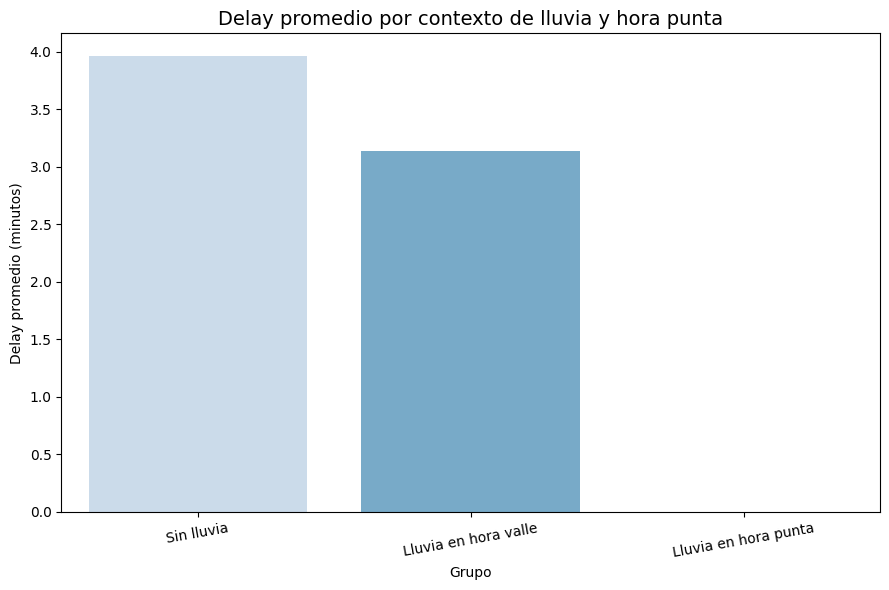

In [92]:
# Interacción lluvia x hora punta
df_master['rain_x_peak'] = ((df_master['Precipitation'] > 0) & (df_master['is_peak'] == 1)).astype(int)

# Definimos 3 grupos mutuamente excluyentes
df_master['grupo_lluvia_peak'] = 'Sin lluvia'
df_master.loc[(df_master['Precipitation'] > 0) & (df_master['is_peak'] == 0), 'grupo_lluvia_peak'] = 'Lluvia en hora valle'
df_master.loc[df_master['rain_x_peak'] == 1, 'grupo_lluvia_peak'] = 'Lluvia en hora punta'

orden_grupos = ['Sin lluvia', 'Lluvia en hora valle', 'Lluvia en hora punta']

plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_master,
    x='grupo_lluvia_peak',
    y='delay_minutes',
    order=orden_grupos,
    estimator=np.mean,
    errorbar=None,
    palette='Blues'
 )
plt.title('Delay promedio por contexto de lluvia y hora punta', fontsize=14)
plt.xlabel('Grupo')
plt.ylabel('Delay promedio (minutos)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 3) Exterior vs subterráneo (Topología)

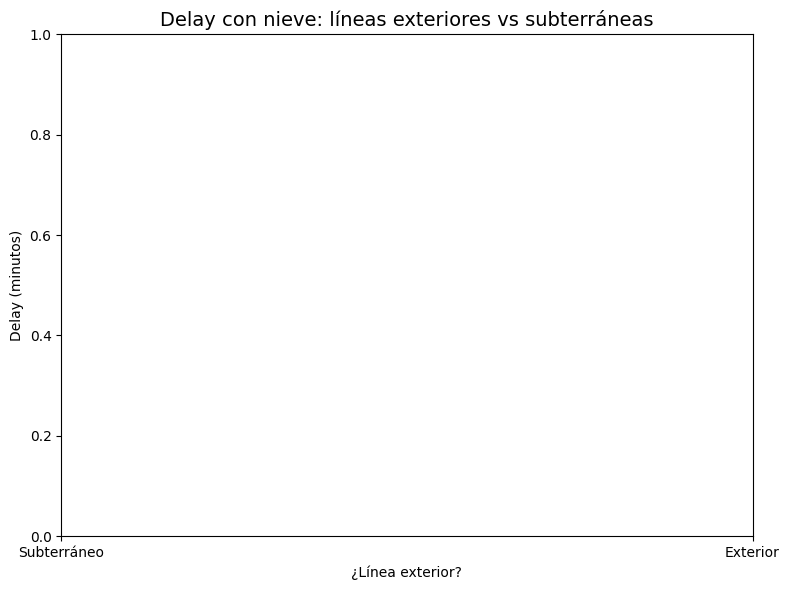

In [93]:
lineas_exteriores = ['7', 'N', 'Q', 'J', 'Z', 'B', 'D']

# True si la línea tiene mucho tramo exterior
df_master['is_exterior'] = df_master['route_id'].astype(str).isin(lineas_exteriores)

# Filtramos solo observaciones con nieve
df_snow = df_master[df_master['Snow'] > 0].copy()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_snow,
    x='is_exterior',
    y='delay_minutes',
    showfliers=False,
    palette='Set3'
 )
plt.title('Delay con nieve: líneas exteriores vs subterráneas', fontsize=14)
plt.xlabel('¿Línea exterior?')
plt.ylabel('Delay (minutos)')
plt.xticks([0, 1], ['Subterráneo', 'Exterior'])
plt.tight_layout()
plt.show()

## 4) Predicción de la recuperación (Delta)

,avg_delta_delay_30m
condicion_clima,
Seco,-144.177509
Lluvia,-128.752730


C:\Users\2alex\AppData\Local\Temp\ipykernel_35240\1353782592.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


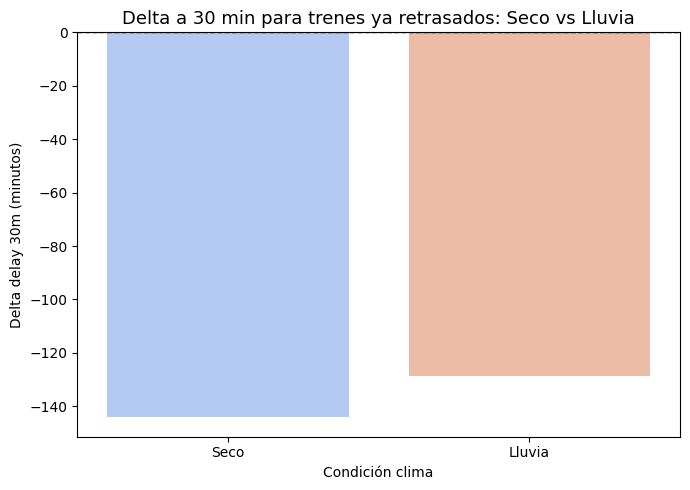

In [94]:
# Creamos/normalizamos condición climática: Seco vs Lluvia
df_master['condicion_clima'] = np.where(df_master['Precipitation'] > 0, 'Lluvia', 'Seco')

# Filtramos trenes que ya van tarde
df_tarde = df_master[df_master['delay_minutes'] > 2].copy()

# Media de delta_delay_30m por condición climática
delta_por_clima = (
    df_tarde.groupby('condicion_clima', dropna=False)['delta_delay_30m']
    .mean()
    .reindex(['Seco', 'Lluvia'])
    .rename('avg_delta_delay_30m')
)
display(delta_por_clima.to_frame())

plt.figure(figsize=(7, 5))
sns.barplot(
    x=delta_por_clima.index,
    y=delta_por_clima.values,
    palette='coolwarm',
    errorbar=None
 )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Delta a 30 min para trenes ya retrasados: Seco vs Lluvia', fontsize=13)
plt.xlabel('Condición clima')
plt.ylabel('Delta delay 30m (minutos)')
plt.tight_layout()
plt.show()